# Segmentation RFM pour le projet GlobalShop Direct

## Préparation 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df_raw = pd.read_excel("../data/raw/Online_Retail.xlsx")

In [3]:
df_raw.to_csv("../data/raw/online_retail.csv", index=False)

In [4]:
print(df_raw.columns.tolist())
df_raw.head()

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df_raw.shape

(541909, 8)

Le dataset comprend 541 909 lignes et 8 colonnes.

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


- InvoiceDate est déjà au format date (datetime64).

- 4 colonnes sont de type texte (object), 2 sont de type décimal (float64) et 1 est de type entier (int64).

In [7]:
df_raw.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Deux colonnes ont des valeurs manquantes :
- CustomerID : 135 080 valeurs manquantes.
- Description : 1 454 valeurs manquantes. 

In [8]:
df_raw.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


- **Période couverte** : du 01/12/2010 au 09/12/2011.
- **Quantity** : le minimum est de **-80 995**. 
- **UnitPrice** : le minimum est de **-11 062,06**.
- La moyenne est bien plus élevée que la médiane (Quantity : 9,55 contre 3 ; UnitPrice : 4,61 contre 2,08), à cause de quelques valeurs très grandes.

## 1) Nettoyage 

### 1.1 Suppression des lignes 

In [9]:
df_clean = df_raw.copy()

Lignes_avant = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["CustomerID"])
Lignes_apres = df_clean.shape[0]

print("Lignes avant :", Lignes_avant)
print("Lignes aprés :", Lignes_apres)
print("Lignes supprimées:", Lignes_avant - Lignes_apres)

Lignes avant : 541909
Lignes aprés : 406829
Lignes supprimées: 135080


### 1.2 créer une colonne pour les factures annulées (C)

In [10]:
df_clean["Annulation"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

print("Lignes d'annulation :", df_clean["Annulation"].sum())
print("Lignes d'achat :", (~df_clean["Annulation"]).sum())

Lignes d'annulation : 8905
Lignes d'achat : 397924


### 1.3 Garder que Quantités et prix positifs (hors annulations)

In [11]:
Lignes_avant = df_clean.shape[0]

df_clean = df_clean[df_clean["UnitPrice"] > 0]
df_clean = df_clean[(df_clean["Quantity"] > 0) | df_clean["Annulation"]]
Lignes_apres = df_clean.shape[0]

print("Lignes avant :", Lignes_avant)
print("Lignes après :", Lignes_apres)
print("Lignes supprimées :", Lignes_avant - Lignes_apres)

Lignes avant : 406829
Lignes après : 406789
Lignes supprimées : 40


### 1.4 Suppression des doublons

In [12]:
Lignes_avant = df_clean.shape[0]
print(" Doublons trouvés :", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()
Lignes_apres = df_clean.shape[0]

print("Lignes avant:", Lignes_avant)
print("Lignes après:", Lignes_apres)
print("Lignes supprimées:", Lignes_avant - Lignes_apres)

 Doublons trouvés : 5225
Lignes avant: 406789
Lignes après: 401564
Lignes supprimées: 5225


### 1.5 Conversion des types (InvoiceDate, CustomerID)

In [13]:
# On vérifie que chaque colonne a le type adapté à son usage : une date pour calculer la récence, un entier pour l'identifiant client
print("Avant :")
print(df_clean[["InvoiceDate", "CustomerID"]].dtypes)

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

print("Après:")
print(df_clean[["InvoiceDate", "CustomerID"]].dtypes)

Avant :
InvoiceDate    datetime64[ns]
CustomerID            float64
dtype: object
Après:
InvoiceDate    datetime64[ns]
CustomerID              int64
dtype: object


- InvoiceDate était déjà au format date (datetime64) : la conversion sert de sécurité, sans rien changer.
- CustomerID passe de décimal (float64) à entier (int64). L'identifiant était stocké en décimal à cause des valeurs manquantes. Une fois celles-ci supprimées, on le repasse en entier pour qu'il reste un identifiant propre, notamment dans les fichiers exportés vers Looker Studio.

### 1.6 Création de la colonne TotalPrice
le fichier ne contient pas le montant de chaque ligne. Il donne seulement la quantité et le prix unitaire.

In [14]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("Montant total des achats :", round(df_clean.loc[~df_clean["Annulation"], "TotalPrice"].sum(), 2))
print("Montant total des annulations :", round(df_clean.loc[df_clean["Annulation"], "TotalPrice"].sum(), 2))
print("Montant net :", round(df_clean["TotalPrice"].sum(), 2))

df_clean[["Quantity", "UnitPrice", "TotalPrice", "Annulation"]].head()

Montant total des achats : 8887208.89
Montant total des annulations : -608689.47
Montant net : 8278519.42


,Quantity,UnitPrice,TotalPrice,Annulation
0,6,2.55,15.30,False
1,6,3.39,20.34,False
2,8,2.75,22.00,False
3,6,3.39,20.34,False
4,6,3.39,20.34,False


In [15]:
round(-df_clean.loc[df_clean["Annulation"], "TotalPrice"].sum() / df_clean.loc[~df_clean["Annulation"], "TotalPrice"].sum() * 100, 1)
print("Part des annulations :", round(-df_clean.loc[df_clean["Annulation"], "TotalPrice"].sum() / df_clean.loc[~df_clean["Annulation"], "TotalPrice"].sum() * 100, 1), "%")

Part des annulations : 6.8 %


### 1.7 Bilan du nettoyage et sauvegarde

In [16]:
print("Lignes au départ :", df_raw.shape[0])
print("Lignes après nettoyage :", df_clean.shape[0])
print("Lignes supprimées au total :", df_raw.shape[0] - df_clean.shape[0])
print("Nombre de clients :", df_clean["CustomerID"].nunique())
print("Période : du", df_clean["InvoiceDate"].min(), "au", df_clean["InvoiceDate"].max())

df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

Lignes au départ : 541909
Lignes après nettoyage : 401564
Lignes supprimées au total : 140345
Nombre de clients : 4371
Période : du 2010-12-01 08:26:00 au 2011-12-09 12:50:00


**Bilan du nettoyage :**
- On passe de **541 909** à **401 564 lignes**.
- Il reste **4 371 clients** différents.
- Période couverte : du 01/12/2010 au 09/12/2011.

Les données nettoyées sont enregistrées dans `data/processed/online_retail_clean.csv`.

## 2) Construction du dataset RFM

### 2.1 Date de référence

In [17]:
achats = df_clean[~df_clean["Annulation"]] # achats contient uniquement les achats, sans les annulations.

date_reference = achats["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Date de référence :", date_reference)

Date de référence : 2011-12-10 12:50:00


**Date de référence :**

- Pour le RFM, on garde uniquement les achats (les annulations sont exclues).
- La date de référence est le lendemain du dernier achat : **10/12/2011 à 12h50**.
- Elle sert à calculer la Recency : le nombre de jours entre le dernier achat d'un client et cette date.


### 2.2 Calcul RFM

In [18]:
rfm = achats.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (date_reference - x.max()).days),
    Frequency=("InvoiceNo", "nunique")
)

rfm["Monetary"] = df_clean.groupby("CustomerID")["TotalPrice"].sum().round(2)

print("Clients avant filtre :", rfm.shape[0])
print("Clients avec Monetary <= 0 :", (rfm["Monetary"] <= 0).sum())

rfm = rfm[rfm["Monetary"] > 0]

print("Clients après filtre :", rfm.shape[0])
rfm.head()

Clients avant filtre : 4338
Clients avec Monetary <= 0 : 21
Clients après filtre : 4317


,Recency,Frequency,Monetary
CustomerID,,,
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
12352,36,8,1545.41


**Calcul RFM :**

- **Recency** : nombre de jours entre le dernier achat du client et la date de référence.
- **Frequency** : nombre de factures différentes (commandes) du client.
- **Monetary** : montant net dépensé en £ (livre sterling), achats moins annulations.

Résultats :

- **4 338 clients** ont au moins un achat.
- **16 clients** ont un montant net nul ou négatif : ils sont retirés.
- Il reste **4 322 clients** dans le dataset RFM.

In [19]:
print("Clients sans aucun achat :", df_clean["CustomerID"].nunique() - achats["CustomerID"].nunique())

Clients sans aucun achat : 33


- Le nettoyage comptait 4 371 clients : **33 clients** n'ont que des annulations (aucun achat), ils n'apparaissent donc pas dans le RFM.

### 2.3 Statistiques descriptives et distributions

       Recency  Frequency   Monetary
count  4317.00    4317.00    4317.00
mean     92.25       4.29    1920.72
std      99.84       7.71    8267.02
min       1.00       1.00       2.90
25%      18.00       1.00     301.03
50%      51.00       2.00     653.75
75%     141.00       5.00    1624.21
max     374.00     209.00  279489.02


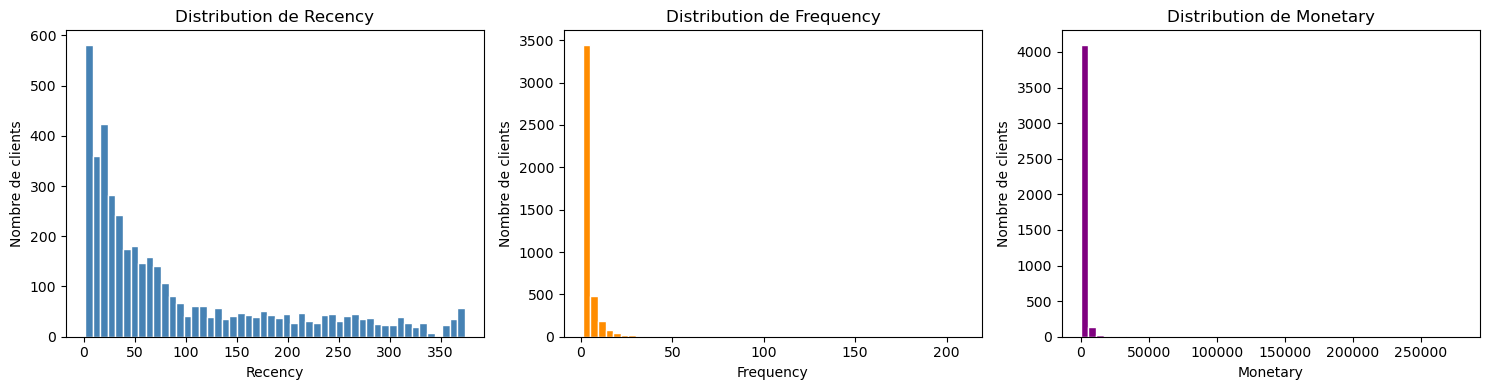

In [20]:
PALETTE = ["steelblue", "darkorange", "purple", "gold", "black", "grey"]

print(rfm.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    axes[i].hist(rfm[col], bins=50, color=PALETTE[i], edgecolor="white")
    axes[i].set_title("Distribution de " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

**Ce que montrent les statistiques**

Après nettoyage, il nous reste 4 317 clients.

Côté **Recency**, la moitié des clients a acheté pour la dernière fois il y a 51 jours ou moins. Mais l'écart est grand : certains sont revenus la veille (1 jour), d'autres n'ont rien acheté depuis 374 jours.

Côté **Frequency**, la plupart des clients commandent peu : la moitié a passé 2 commandes ou moins, et les trois quarts 5 commandes ou moins. À l'opposé, un client a passé 209 commandes.

Côté **Monetary**, on retrouve la même chose : la moitié des clients a dépensé 653,75 £ ou moins. Le plus gros client, lui, a dépensé 279 489,02 £.

Pour les trois variables, la moyenne est plus élevée que la médiane (par exemple 1 920,72  contre 653,75  pour Monetary). Quelques clients aux valeurs très élevées tirent la moyenne vers le haut. Les histogrammes le montrent bien : la grande majorité des clients est regroupée à gauche, avec une longue traîne de quelques clients exceptionnels.

Ces distributions semblent donc asymétriques. 

### 2.4 Sauvegarde de rfm.csv

In [21]:
rfm.to_csv("../data/processed/rfm.csv")

print("Fichier enregistré :", rfm.shape[0], "clients,", rfm.shape[1], "colonnes")

Fichier enregistré : 4317 clients, 3 colonnes


## 3) Prétraitement

### 3.1 Mesure de l'asymétrie

In [23]:
FEATURES = ["Recency", "Frequency", "Monetary"]

print("Asymétrie (skewness) :")
print(rfm[FEATURES].skew().round(2))

Asymétrie (skewness) :
Recency       1.25
Frequency    12.05
Monetary     21.59
dtype: float64


Chaque variable a une longue traîne vers la droite. Beaucoup de clients ont de petites valeurs, et quelques-uns ont des valeurs très élevées.

- **Recency : 1,25.** L'asymétrie est réelle, mais c'est la plus modérée des trois.
- **Frequency : 12,05.** Elle est très forte.
- **Monetary : 21,59.** C'est la plus forte des trois

Les trois valeurs dépassent 1, le seuil souvent utilisé pour parler de forte asymétrie. Si on laissait les données telles quelles, quelques clients extrêmes pèseraient trop dans le calcul des distances de K-means. 

### 3.2 Transformation log1p

Asymétrie après log1p :
Recency     -0.38
Frequency    1.20
Monetary     0.38
dtype: float64


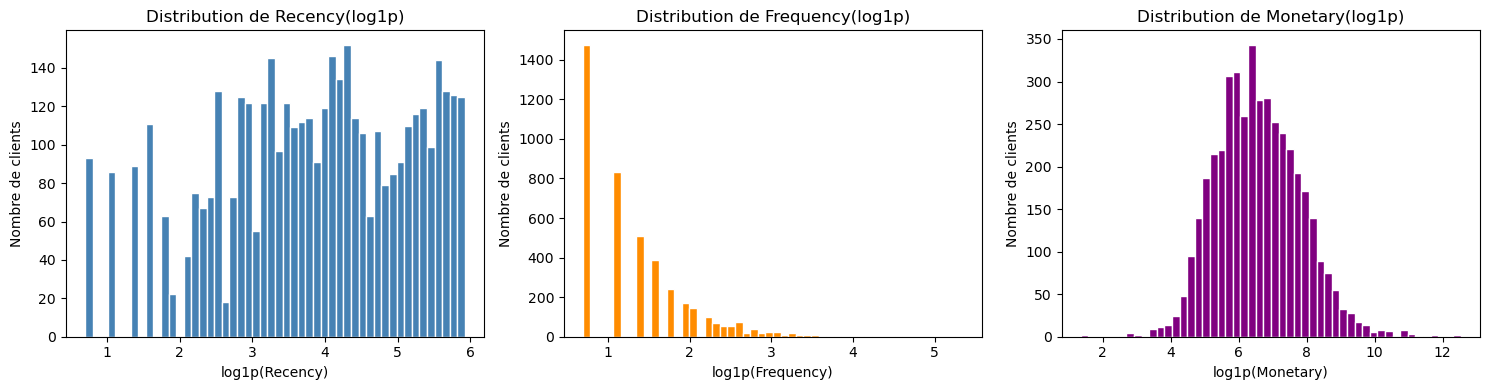

In [25]:
rfm_log = np.log1p(rfm[FEATURES])

print("Asymétrie après log1p :")
print(rfm_log.skew().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(FEATURES):
    axes[i].hist(rfm_log[col], bins=50, color=PALETTE[i], edgecolor="white")
    axes[i].set_title("Distribution de " + col + "(log1p)")
    axes[i].set_xlabel("log1p(" + col + ")")
    axes[i].set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

- **Monetary** est la variable qui gagne le plus : son asymétrie passe de 21,59 à 0,38. L'histogramme a maintenant une forme proche d'une cloche.
- **Recency** passe de 1,25 à -0,38. Le signe négatif indique simplement une légère traîne vers la gauche, mais l'asymétrie reste faible.
- **Frequency** passe de 12,05 à 1,20. C'est une très forte baisse.

### 3.3 Standardisation

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=FEATURES,
    index=rfm_log.index
)

print(rfm_scaled.describe().round(2))

       Recency  Frequency  Monetary
count  4317.00    4317.00   4317.00
mean     -0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -2.34      -0.96     -4.18
25%      -0.66      -0.96     -0.69
50%       0.09      -0.37     -0.07
75%       0.84       0.65      0.66
max       1.57       5.85      4.80


Après le log, les trois variables n'étaient toujours pas sur la même échelle. On les standardise avec `StandardScaler` : pour chaque valeur, on retire la moyenne de la colonne puis on divise par son écart-type.

Le `describe()` le confirme : les trois variables ont maintenant une **moyenne de 0** et un **écart-type de 1**. 

Les trois variables ont maintenant le même poids : K-means pourra comparer les clients sans qu'une variable domine les autres.

### 3.4 Sauvegarde du scaler

On sauvegarde le scaler et le modèle pour que l'application applique exactement les mêmes transformations et la même segmentation aux nouveaux clients, sans réentraîner le modèle.

In [28]:
import joblib

joblib.dump(scaler,"../models/scaler.joblib")

scaler_charge = joblib.load("../models/scaler.joblib")
print("Scaler rechargé identique :", np.allclose(scaler_charge.transform(rfm_log), rfm_scaled))

Scaler rechargé identique : True


## 4) Clustering

### 4.1 Méthode du coude

K= 2 : inertie = 6440.36
K= 3 : inertie = 4824.79
K= 4 : inertie = 3895.48
K= 5 : inertie = 3255.48
K= 6 : inertie = 2817.49
K= 7 : inertie = 2513.87
K= 8 : inertie = 2302.05
K= 9 : inertie = 2125.22
K= 10 : inertie = 1967.77


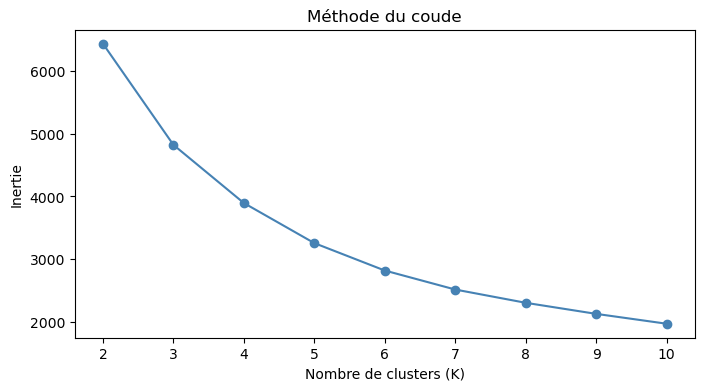

In [31]:
from sklearn.cluster import KMeans

RANDOM_STATE = 42

k_valeurs = range(2, 11)
inerties = []

for k in k_valeurs:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(rfm_scaled)
    inerties.append(km.inertia_)

for k, inertie in zip(k_valeurs, inerties):
    print("K=", k, ": inertie =", round(inertie, 2))

plt.figure(figsize=(8, 4))
plt.plot(k_valeurs, inerties, marker="o", color=PALETTE[0])
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.xticks(k_valeurs)
plt.show()

On entraîne un K-means pour chaque K entre 2 et 10, et on note l'inertie : la somme des distances au carré entre chaque client et le centre de son cluster. Plus elle est faible, plus les groupes sont compacts.
La courbe descend de façon régulière, sans coude vraiment net. La méthode du coude ne suffit donc pas à choisir K seule : on la complète avec le score de silhouette.

### 4.2 Score de silhouette

K = 2 : silhouette = 0.433
K = 3 : silhouette = 0.338
K = 4 : silhouette = 0.339
K = 5 : silhouette = 0.32
K = 6 : silhouette = 0.313
K = 7 : silhouette = 0.31
K = 8 : silhouette = 0.304
K = 9 : silhouette = 0.281
K = 10 : silhouette = 0.279


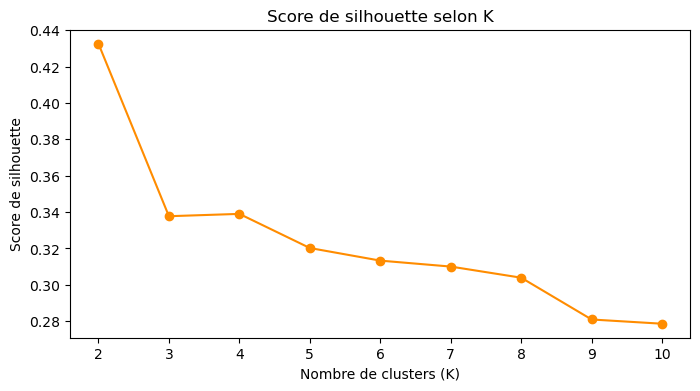

In [36]:
from sklearn.metrics import silhouette_score

silhouettes = []

for k in k_valeurs :
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

for k, score in zip(k_valeurs, silhouettes):
    print("K =", k, ": silhouette =", round(score, 3))

plt.figure(figsize=(8, 4))
plt.plot(k_valeurs, silhouettes, marker="o", color=PALETTE[1])
plt.title("Score de silhouette selon K")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Score de silhouette")
plt.xticks(k_valeurs)
plt.show()
    

Le score de silhouette mesure à la fois si les clusters sont compacts et s'ils sont bien séparés les uns des autres. Il va de -1 à 1 : plus il est élevé, mieux c'est.

- Le meilleur score est obtenu pour **K = 2 est à presque (0,44)**.
- Il chute ensuite nettement : **presque 0,33 pour K = 3** et aussi presquee **0,33 pour K = 4**, deux scores presque identiques.
- Au-delà de K = 4, le score baisse régulièrement, jusqu'à presque 0,27 pour K = 10.

Tous les scores sont positifs : les clients sont globalement bien rattachés à leur cluster.

In [37]:
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(rfm_scaled)

    resume = rfm.groupby(labels).agg(
        Nb_clients=("Recency", "size"),
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        Monetary=("Monetary", "mean")
    ).round(1)

    print("===== K =", k, "=====")
    print(resume)
    print()

===== K = 2 =====
   Nb_clients  Recency  Frequency  Monetary
0        2656    133.9        1.7     484.2
1        1661     25.7        8.5    4217.8

===== K = 3 =====
   Nb_clients  Recency  Frequency  Monetary
0        1874    166.0        1.4     354.3
1         753     15.9       13.5    7395.2
2        1690     44.5        3.4    1218.5

===== K = 4 =====
   Nb_clients  Recency  Frequency  Monetary
0        1180     70.0        4.1    1639.2
1        1613    181.5        1.3     333.9
2         827     17.4        2.2     552.0
3         697     12.1       13.9    7693.5



**Choix du nombre de clusters**

Les deux méthodes ne donnent pas exactement la même réponse :

- la **silhouette** est la meilleure pour K = 2, puis presque identique pour K = 3  et K = 4  ;
- au **coude**, les deux plus fortes baisses d'inertie sont obtenues en passant à K = 3  et à K = 4 .

Pour trancher, on a comparé concrètement les groupes obtenus avec K = 2, 3 et 4 (moyennes réelles de R, F et M) :

- **K = 2** sépare seulement les bons clients des moins bons. C'est trop simple pour proposer des actions marketing variées.
- **K = 3** ajoute un groupe intermédiaire (44,5 jours, 3,4 commandes, 1 218,5 £ en moyenne).
- **K = 4** coupe ce groupe intermédiaire en deux profils bien différents : des clients **récents mais qui commandent peu** (827 clients : 17,4 jours, 2,2 commandes, 552,0 £) et des clients **qui ont commandé plus souvent mais moins récemment** (1 180 clients : 70,0 jours, 4,1 commandes, 1 639,2 £).

On retient donc **K = 4**. Sa silhouette est au même niveau que K = 3, il fait partie des deux plus fortes baisses au coude, et il donne quatre segments distincts, tous de taille suffisante (le plus petit compte 697 clients), sur lesquels GlobalShop Direct peut agir différemment.

### 4.4 K-means final et sauvegarde du modèle

In [38]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Nombre de clients par cluster :")
print(rfm["Cluster"].value_counts().sort_index())

joblib.dump(kmeans, "../models/kmeans.joblib")

kmeans_charge = joblib.load("../models/kmeans.joblib")
print("Modèle rechargé identique :", (kmeans_charge.predict(rfm_scaled) == rfm["Cluster"]).all())



Nombre de clients par cluster :
Cluster
0    1180
1    1613
2     827
3     697
Name: count, dtype: int64
Modèle rechargé identique : True


On entraîne le modèle final avec K = 4, avec les mêmes réglages que pendant les tests (`random_state = 42`, `n_init = 10`). Chaque client reçoit un numéro de cluster, rangé dans une nouvelle colonne `Cluster` du tableau `rfm`.
Ces effectifs sont identiques à ceux obtenus lors de la comparaison en 4.3 : le modèle final correspond bien au choix de K = 4.

Le modèle est enregistré dans `models/kmeans.joblib`. Après rechargement, il classe tous les clients exactement de la même façon (`True`). L'application Streamlit pourra donc l'utiliser pour prédire le segment d'un nouveau client.

### 4.5 Clustering hiérarchique 

Hauteur de coupure pour 4 clusters : 36.97


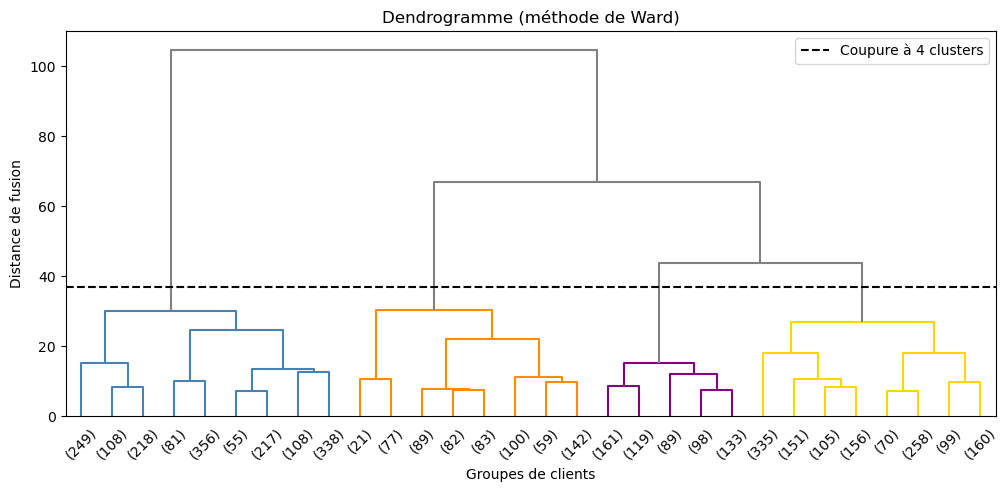

Hauteurs des 5 dernières fusions : [ 29.99  30.28  43.66  66.94 104.75]


In [41]:
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette

liens = linkage(rfm_scaled, method="ward")

hauteur_coupe = (liens[-K_FINAL, 2] + liens[-(K_FINAL - 1), 2]) / 2
print("Hauteur de coupure pour", K_FINAL, "clusters :", round(hauteur_coupe, 2))

set_link_color_palette(PALETTE[:K_FINAL])

plt.figure(figsize=(12, 5))
dendrogram(
    liens,
    truncate_mode="lastp",
    p=30,
    color_threshold=hauteur_coupe,
    above_threshold_color="grey"
)
plt.axhline(y=hauteur_coupe, color="black", linestyle="--", label="Coupure à " + str(K_FINAL) + " clusters")
plt.title("Dendrogramme (méthode de Ward)")
plt.xlabel("Groupes de clients")
plt.ylabel("Distance de fusion")
plt.legend()
plt.show()
print("Hauteurs des 5 dernières fusions :", liens[-5:, 2].round(2))

les écarts entre fusions sont plus grands en haut de l'arbre qu'au niveau de notre coupure. Comme la silhouette, le dendrogramme montre que 2 ou 3 groupes seraient plus « naturels » mathématiquement. On garde K = 4 pour la raison métier expliquée en 4.3 : séparer les clients récents mais peu actifs des clients réguliers moins récents.
Pour vérifier notre choix, on utilise une deuxième méthode : le clustering hiérarchique. Au départ, chaque client forme son propre groupe, puis l'algorithme fusionne pas à pas les deux groupes les plus proches. Le dendrogramme montre ces fusions : plus une fusion est haute, plus les groupes réunis sont différents.

Pour obtenir 4 clusters, on coupe l'arbre à une hauteur de **36,97**, au milieu entre la fusion à 30,28 (dernière fusion à l'intérieur des clusters) et celle à 43,66 (première fusion entre deux clusters).

- La branche **violette** et la branche **dorée** fusionnent à 43,66, juste au-dessus de la coupure : ce sont les deux clusters les plus proches.
- La branche **bleue** ne rejoint les autres qu'à la toute dernière fusion (104,75) : c'est le groupe le plus différent.

Comme pour la silhouette, les plus grandes distances se trouvent en haut de l'arbre : mathématiquement, un découpage en 2 ou 3 groupes serait plus marqué. On garde K = 4 pour son intérêt métier.

In [42]:
from sklearn.cluster import AgglomerativeClustering

hierarchique = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
labels_hier = hierarchique.fit_predict(rfm_scaled)

print("Silhouette K-means :", round(silhouette_score(rfm_scaled, rfm["Cluster"]), 3))
print("Silhouette hiérarchique :", round(silhouette_score(rfm_scaled, labels_hier), 3))

print("\nCorrespondance entre les deux méthodes :")
print(pd.crosstab(rfm["Cluster"], labels_hier, rownames=["K-means"], colnames=["Hiérarchique"]))

Silhouette K-means : 0.339
Silhouette hiérarchique : 0.304

Correspondance entre les deux méthodes :
Hiérarchique    0     1     2    3
K-means                           
0              16    89  1062   13
1               0  1515    97    1
2              70   126    46  585
3             567     0   129    1


In [43]:
tableau = pd.crosstab(rfm["Cluster"], labels_hier)

accord = tableau.max(axis=1).sum() / tableau.values.sum() * 100
print("Clients classés dans le même groupe par les deux méthodes :", round(accord, 1), "%")


Clients classés dans le même groupe par les deux méthodes : 86.4 %


- **Silhouette** : 0,339 pour K-means contre 0,304 pour le hiérarchique. K-means sépare un peu mieux les groupes.
- Au total, **86,4 %** des clients sont classés dans le même groupe par les deux méthodes.

Le cluster 1 est le plus stable (1 515 clients). Le cluster 2 est le plus partagé (585 clients) : ses clients sont plus proches des autres groupes.

Deux méthodes différentes aboutissent en grande partie aux mêmes groupes : On garde K-means, qui a la meilleure silhouette et qui peut classer un nouveau client avec `predict`, ce qui est indispensable pour l'application Streamlit.

## 5) PCA et profilage

### 5.1 Analyse en composantes principales (PCA)

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(rfm_scaled)

variance = pd.DataFrame({
    "Variance expliquée (%)": pca.explained_variance_ratio_ * 100,
    "Variance cumulée (%)": pca.explained_variance_ratio_.cumsum() * 100
}, index=["PC1", "PC2", "PC3"])

print("Part d'information gardée par chaque axe :")
print(variance.round(2))

contributions = pd.DataFrame(pca.components_, columns=FEATURES, index=["PC1", "PC2", "PC3"])

print("\nPoids de chaque variable dans les axes :")
print(contributions.round(2))

Part d'information gardée par chaque axe :
     Variance expliquée (%)  Variance cumulée (%)
PC1                   75.25                 75.25
PC2                   18.76                 94.01
PC3                    5.99                100.00

Poids de chaque variable dans les axes :
     Recency  Frequency  Monetary
PC1    -0.51       0.62      0.60
PC2     0.85       0.27      0.45
PC3     0.12       0.74     -0.66


Les deux premiers axes gardent **94,01 %** de l'information : un graphique en 2D sera donc fidèle à la réalité.

**Ce que représentent les axes**, d'après le poids de chaque variable :

- **PC1** mélange les trois variables avec des poids proches (Recency -0,51, Frequency 0,62, Monetary 0,60). Plus un client est à droite, plus il commande souvent, dépense beaucoup et a acheté récemment. C'est un axe de **valeur globale du client**.
- **PC2** est surtout porté par **Recency** (0,85). Plus un client est haut, plus son dernier achat est ancien.
- **PC3** oppose Frequency (0,74) et Monetary (-0,66), mais ne porte que 5,99 % de l'information : on ne l'utilise pas pour la visualisation.

### 5.2 Visualisation des clusters en 2D

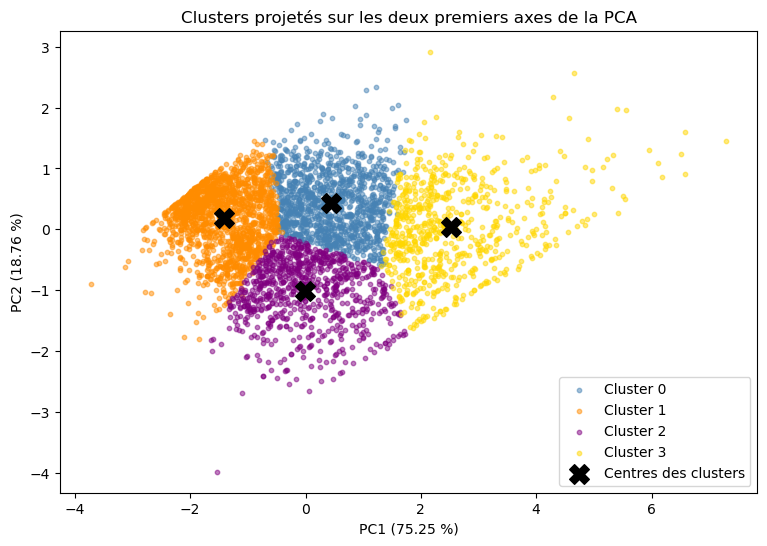

In [45]:
coords = pca.transform(rfm_scaled)

rfm_pca = pd.DataFrame(coords[:, :2], columns=["PC1", "PC2"], index=rfm_scaled.index)
rfm_pca["Cluster"] = rfm["Cluster"]

centres = pca.transform(pd.DataFrame(kmeans.cluster_centers_, columns=FEATURES))

plt.figure(figsize=(9, 6))

for c in range(K_FINAL):
    groupe = rfm_pca[rfm_pca["Cluster"] == c]
    plt.scatter(groupe["PC1"], groupe["PC2"], s=10, alpha=0.5, color=PALETTE[c], label="Cluster " + str(c))

plt.scatter(centres[:, 0], centres[:, 1], marker="X", s=200, color="black", label="Centres des clusters")

plt.title("Clusters projetés sur les deux premiers axes de la PCA")
plt.xlabel("PC1 (" + str(round(variance.loc["PC1", "Variance expliquée (%)"], 2)) + " %)")
plt.ylabel("PC2 (" + str(round(variance.loc["PC2", "Variance expliquée (%)"], 2)) + " %)")
plt.legend()
plt.show()

On projette les clients sur les deux premiers axes de la PCA, qui gardent 94,01 % de l'information. Chaque couleur est un cluster, et les croix noires sont les centres.

- **Cluster 1 (orange)**, à gauche : les clients de plus faible valeur (dernier achat ancien, peu de commandes, petit montant).
- **Cluster 3 (doré)**, à droite : les clients de plus forte valeur. C'est aussi le groupe le plus étalé, avec quelques clients isolés très loin à droite.
- **Clusters 0 (bleu) et 2 (violet)**, au centre : ils ont une valeur intermédiaire, mais se séparent sur l'axe vertical, lié surtout à la Recency. Le cluster 2 est plus bas (achats plus récents), le cluster 0 plus haut (achats moins récents).

Les quatre groupes occupent des zones distinctes, mais se touchent sans espace vide entre eux. C'est cohérent avec le score de silhouette (0,339) : les comportements clients forment un continuum plutôt que des groupes totalement séparés.

### 5.3 Profils des clusters

In [46]:
profils = rfm.groupby("Cluster").agg(
    Nb_clients=("Recency", "size"),
    Recency_moyenne=("Recency", "mean"),
    Recency_mediane=("Recency", "median"),
    Frequency_moyenne=("Frequency", "mean"),
    Frequency_mediane=("Frequency", "median"),
    Monetary_moyen=("Monetary", "mean"),
    Monetary_median=("Monetary", "median"),
    Monetary_total=("Monetary", "sum")
)

profils["Part_clients (%)"] = profils["Nb_clients"] / profils["Nb_clients"].sum() * 100
profils["Part_CA (%)"] = profils["Monetary_total"] / profils["Monetary_total"].sum() * 100

print(profils.round(1).T)

Cluster                    0         1         2          3
Nb_clients            1180.0    1613.0     827.0      697.0
Recency_moyenne         70.0     181.5      17.4       12.1
Recency_mediane         55.0     175.0      17.0        8.0
Frequency_moyenne        4.1       1.3       2.2       13.9
Frequency_mediane        4.0       1.0       2.0       10.0
Monetary_moyen        1639.2     333.9     552.0     7693.5
Monetary_median       1314.1     288.2     467.0     3669.9
Monetary_total     1934224.1  538658.0  456519.8  5362346.7
Part_clients (%)        27.3      37.4      19.2       16.1
Part_CA (%)             23.3       6.5       5.5       64.7


le cluster 3 représente 16,1 % des clients, mais 64,7 % du chiffre d'affaires.

- **Cluster 3** : les meilleurs clients. Ils ont acheté très récemment, commandent souvent et dépensent beaucoup. Ils ne sont que 16,1 % mais rapportent **64,7 % du chiffre d'affaires**. Leur montant moyen (7 693,5 £) est deux fois plus élevé que leur montant médian (3 669,9 £) : quelques très gros clients tirent la moyenne vers le haut.
- **Cluster 0** : des clients réguliers (4 commandes en médiane, 1 314,1 £), mais dont le dernier achat est moins récent (55 jours). Ils pèsent 23,3 % du chiffre d'affaires.
- **Cluster 2** : des clients récents (17 jours) qui ont encore peu commandé (2 commandes, 467,0 £). Ils représentent 19,2 % des clients pour 5,5 % du chiffre d'affaires.

### 5.4 Personas 

In [47]:
import json

PERSONAS = {
    0: "Les Habitués",
    1: "Les Endormis",
    2: "Les Curieux",
    3: "Les Fans"
}

rfm["Persona"] = rfm["Cluster"].map(PERSONAS)
print(rfm["Persona"].value_counts())

with open("../models/personas.json", "w", encoding="utf-8") as f:
    json.dump(PERSONAS, f, ensure_ascii=False, indent=2)

Persona
Les Endormis    1613
Les Habitués    1180
Les Curieux      827
Les Fans         697
Name: count, dtype: int64


On donne à chaque cluster un nom simple, facile à utiliser dans une communication client. Chaque nom résume le profil chiffré du groupe.

**Les Fans (cluster 3) : 697 clients, 64,7 % du chiffre d'affaires**
Ils ont acheté il y a 8 jours, ont passé 10 commandes et ont dépensé 3 669,9 £. C'est le groupe le plus précieux : 16,1 % des clients rapportent près des deux tiers du chiffre d'affaires.
*Idée d'action : les remercier et les garder (avantages exclusifs, accès en avant-première).*

**Les Habitués (cluster 0) : 1 180 clients, 23,3 % du chiffre d'affaires**
Ils ont passé 4 commandes pour 1 314,1 £, mais leur dernier achat date de 55 jours.
*Idée d'action : une relance personnalisée pour les faire revenir plus souvent.*

**Les Curieux (cluster 2) : 827 clients, 5,5 % du chiffre d'affaires**
Ils ont acheté récemment (17 jours), mais seulement 2 commandes pour 467,0 £.
*Idée d'action : les encourager à commander à nouveau (recommandations, offre sur la prochaine commande).*

**Les Endormis (cluster 1) : 1 613 clients, 6,5 % du chiffre d'affaires**
C'est le groupe le plus nombreux. Leur dernier achat date de 175 jours, avec 1 commande pour 288,2 £.
*Idée d'action : une campagne de réactivation simple et peu coûteuse.*

La correspondance entre numéro de cluster et persona est enregistrée dans `models/personas.json`, pour que l'application Streamlit affiche directement le nom du persona.

## 6. Export pour Looker Studio

In [48]:
export = rfm.join(rfm_pca[["PC1", "PC2"]]).reset_index()

export.to_csv("../data/processed/rfm_looker.csv", index=False, encoding="utf-8")

print("Fichier exporté :", export.shape[0], "clients,", export.shape[1], "colonnes")
export.head()

Fichier exporté : 4317 clients, 8 colonnes


,CustomerID,Recency,Frequency,Monetary,Cluster,Persona,PC1,PC2
0,12347,2,7,4310.00,3,Les Fans,2.565963,-0.790962
1,12348,75,4,1797.24,0,Les Habitués,0.488612,0.759145
2,12349,19,1,1757.55,2,Les Curieux,0.158542,-0.452084
3,12350,310,1,334.40,1,Les Endormis,-1.683292,0.685538
4,12352,36,8,1545.41,0,Les Habitués,1.222210,0.475558


In [49]:
print("Chiffre d'affaires total des clients RFM :", round(export["Monetary"].sum(), 2))

Chiffre d'affaires total des clients RFM : 8291748.56


## 7) Conclusion

**Ce qu'on a fait**

Le fichier de départ contenait 541 909 lignes de ventes, du 01/12/2010 au 09/12/2011. Après nettoyage (lignes sans client, prix nuls, doublons), il reste 401 564 lignes et 4 371 clients. Les annulations n'ont pas été supprimées : elles ont été déduites du montant de chaque client, pour travailler sur un montant **net**.

À partir de ces données, on a calculé pour chaque client sa **Recency** (jours depuis le dernier achat), sa **Frequency** (nombre de commandes) et son **Monetary** (montant net dépensé). Le dataset RFM final compte **4 317 clients**.

Les trois variables étaient très asymétriques (jusqu'à 21,59 pour Monetary). On les a transformées avec log1p, puis standardisées, pour que K-means compare les clients équitablement.

**Le choix de 4 segments**

La méthode du coude ne montrait pas de coude net, et la silhouette était la meilleure pour K = 2 (0,433). On a retenu **K = 4** (silhouette 0,339) parce qu'il donne quatre profils bien distincts, plus utiles pour le marketing. Ce choix a été vérifié avec une deuxième méthode, le clustering hiérarchique : **86,4 %** des clients sont classés de la même façon. La PCA, qui garde 94,01 % de l'information sur deux axes, montre aussi quatre zones bien séparées.

**Les quatre personas**

| Persona | Clients | Part du CA | Profil (médianes) |
|---|---|---|---|
| Les Fans | 697 (16,1 %) | 64,7 % | 8 jours, 10 commandes, 3 669,9 £ |
| Les Habitués | 1 180 (27,3 %) | 23,3 % | 55 jours, 4 commandes, 1 314,1 £ |
| Les Curieux | 827 (19,2 %) | 5,5 % | 17 jours, 2 commandes, 467,0 £ |
| Les Endormis | 1 613 (37,4 %) | 6,5 % | 175 jours, 1 commande, 288,2 £ |

Le résultat le plus marquant : **16,1 % des clients (les Fans) rapportent 64,7 % du chiffre d'affaires**. À l'inverse, les Endormis sont les plus nombreux (37,4 %) mais ne pèsent que 6,5 % du chiffre d'affaires.

**Idées d'action**

- **Les Fans** : les garder, avec des avantages exclusifs.
- **Les Habitués** : les relancer avant qu'ils ne s'éloignent.
- **Les Curieux** : les encourager à passer une nouvelle commande.
- **Les Endormis** : une campagne de réactivation simple et peu coûteuse.

**Limites**

- Les données couvrent environ un an seulement (décembre 2010 à décembre 2011).
- Le score de silhouette (0,339) montre que les groupes se chevauchent en partie : les comportements clients forment un continuum, pas des cases parfaitement séparées.
- K = 4 est un choix métier : mathématiquement, 2 ou 3 groupes seraient plus marqués.
